<a href="https://colab.research.google.com/github/AnneTae/Mobile-Phone-Market/blob/main/Mobile_Phone_Market.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction
In this project, we aim to analyze smartphone data sourced from online platforms, focusing on various features like price, memory, camera quality, and battery capacity. The primary goal is to build predictive models that can forecast smartphone prices based on these features, helping consumers make informed purchasing decisions and assisting retailers in pricing their products competitively.

The dataset includes key attributes such as the price, memory configurations, camera specifications, and battery capacities of various smartphone models. We will also explore additional features like product name length and price categories. The analysis will involve several steps, including data cleaning, exploratory data analysis (EDA), and machine learning model training.


### Why This Is Important:
Smartphone pricing is a complex process influenced by various factors such as memory size, camera capabilities, and battery performance. By analyzing this data, we aim to uncover patterns that can help consumers understand what drives price differences and how specific features impact the cost of a smartphone. Additionally, the insights from the model can be useful for businesses to optimize their pricing strategies.

The results of this project will contribute to a deeper understanding of the smartphone market and provide a tool for predicting smartphone prices, benefiting both consumers and retailers alike.

# Data scraping

**Tools Used & Approach**

To collect product data, we use the following tools:

**BeautifulSoup**: A Python library for parsing HTML and extracting relevant
elements. It's lightweight and suitable for scraping websites with static content.

**requests**: Used to fetch webpage content from both websites.

**pandas**: Allows structured data storage and manipulation.

**time**: Introduced delays between requests to avoid overwhelming the servers.

We collect smartphone product data from two Armenian websites — 3DPlanet.am and Redstore.am — extracting key specifications like product name, price, memory, camera, and battery. The combined dataset enables later comparison, analysis, and visualization of smartphone offerings.



In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import os

# -------------------- 3DPlanet Scraping --------------------
print("Scraping 3DPlanet.am...")
basic_url = "https://3dplanet.am/product-category/smartphones/page/{}/"
pages_number = 16

product_names = []
product_prices = []
product_urls = []
memories = []
cameras = []
batteries = []

for page_number in range(1, pages_number + 1):
    url = basic_url.format(page_number)
    page = requests.get(url)
    soup = BeautifulSoup(page.content, "html.parser")

    product_smartphones = soup.find_all("div", class_="product-grid-item")

    for item in product_smartphones:
        product_name_tag = item.find('h3', class_='product-title').find('a')
        product_name = product_name_tag.text.strip() if product_name_tag else "N/A"

        product_price_tag = item.find("span", class_="woocommerce-Price-amount amount")
        product_price = product_price_tag.text.strip() if product_price_tag else "Price not available"

        product_link_tag = item.find("a")
        product_link = product_link_tag['href'] if product_link_tag else "Link not available"

        if all((product_name, product_price, product_link)):
            product_names.append(product_name)
            product_prices.append(product_price)
            product_urls.append(product_link)

            try:
                product_page = requests.get(product_link)
                product_soup = BeautifulSoup(product_page.content, "html.parser")

                memory_elem = product_soup.find("tr", class_="woocommerce-product-attributes-item--attribute_pa_memory")
                memory = memory_elem.find("td").text.strip() if memory_elem else "Not available"

                camera_elem = product_soup.find("tr", class_="woocommerce-product-attributes-item--attribute_pa_camera")
                camera = camera_elem.find("td").text.strip() if camera_elem else "Not available"

                battery_elem = product_soup.find("tr", class_="woocommerce-product-attributes-item--attribute_pa_battery")
                battery = battery_elem.find("td").text.strip() if battery_elem else "Not available"

            except Exception as e:
                memory, camera, battery = "Not available", "Not available", "Not available"

            memories.append(memory)
            cameras.append(camera)
            batteries.append(battery)

df_3dplanet = pd.DataFrame({
    'Product Name': product_names,
    'Price': product_prices,
    'Product URL': product_urls,
    'Memory': memories,
    'Camera': cameras,
    'Battery': batteries
})

print("✅ 3DPlanet.am data scraped successfully.\n")

# -------------------- Redstore Scraping --------------------
print("Scraping Redstore.am...")
rs_product_names = []
rs_product_prices = []
rs_product_urls = []
rs_memories = []
rs_cameras = []
rs_batteries = []

for page in range(1, 56):
    url = f"https://redstore.am/shop/category/categories/smartfony"
    response = requests.get(url)
    soup = BeautifulSoup(response.content, "html.parser")

    products = soup.find_all("li", class_="globalFrameProduct to-cart")

    if not products:
        break

    for product in products:
        name_tag = product.find("span", class_="title")
        name = name_tag.text.strip() if name_tag else "N/A"

        price_tag = product.find("span", class_="price priceCashVariant")
        price = price_tag.text.strip() if price_tag else "Price not available"

        link_tag = product.find("a")
        product_link = link_tag['href'] if product_link_tag else "Link not available"

        rs_product_names.append(name)
        rs_product_prices.append(price)
        rs_product_urls.append(product_link)

        memory = camera = battery = "Not available"
        try:
            product_page = requests.get(product_link)
            product_soup = BeautifulSoup(product_page.content, "html.parser")
            spec_table = product_soup.find("ul", class_="tabs tabs-data tabs-product")

            if spec_table:
                rows = spec_table.find_all("tr")
                for row in rows:
                    label = row.find("th").text.strip()
                    value = row.find("td").text.strip()
                    if "Հիշողություն" in label:
                        memory = value
                    elif "Հիմնական տեսախցիկ" in label:
                        camera = value
                    elif "Մարտկոցի հզորություն" in label:
                        battery = value
        except:
            pass

        rs_memories.append(memory)
        rs_cameras.append(camera)
        rs_batteries.append(battery)

        time.sleep(0.3)

df_redstore = pd.DataFrame({
    'Product Name': rs_product_names,
    'Price': rs_product_prices,
    'Product URL': rs_product_urls,
    'Memory': rs_memories,
    'Camera': rs_cameras,
    'Battery': rs_batteries
})

print("✅ Redstore.am data scraped successfully.\n")

# -------------------- Combine and Save --------------------
combined_df = pd.concat([df_3dplanet, df_redstore], ignore_index=True)
combined_df.drop_duplicates(subset=['Product Name', 'Product URL'], inplace=True)
combined_df.reset_index(drop=True, inplace=True)

combined_df.to_csv("combined_smartphones_data.csv", index=False)
print("✅ Combined dataset saved as 'combined_smartphones_data.csv'")


Scraping 3DPlanet.am...
✅ 3DPlanet.am data scraped successfully.

Scraping Redstore.am...
✅ Redstore.am data scraped successfully.

✅ Combined dataset saved as 'combined_smartphones_data.csv'


In [ ]:
df = pd.read_csv("combined_smartphones_data.csv")

# Data Cleaning

In this project, data scraping was the foundational step to gather real-world smartphone specifications and pricing information. Using web scraping techniques, we extracted data from multiple online sources to build a comprehensive dataset. The scraping process involved fetching HTML content, parsing relevant elements (such as brand, memory, battery, camera, and price), and structuring the information into a clean, tabular format suitable for further analysis. This automated approach enabled the collection of large-scale, up-to-date data efficiently, which is crucial for building reliable machine learning models and deriving meaningful insights.

In [ ]:
df

,Product Name,Price,Product URL,Memory,Camera,Battery
0,Iphone 15 Pro 128GB (Natural Titanium),"394,000 AMD",https://3dplanet.am/product/iphone-15-pro-128g...,128GB,"12MP+12MP, 48MP, TOF 3D LiDAR scanner",3274 mAh
1,Iphone 15 Pro 256GB (Blue Titanium),"445,000 AMD",https://3dplanet.am/product/iphone-15-pro-256g...,256GB,"12MP+12MP, 48MP, TOF 3D LiDAR scanner",3274 mAh
2,Iphone 15 Pro 512GB (White Titanium),"538,000 AMD",https://3dplanet.am/product/iphone-15-pro-512g...,512GB,"12MP+12MP, 48MP, TOF 3D LiDAR scanner",3274 mAh
3,Iphone 15 Pro 1TB (Black Titanium),"619,000 AMD",https://3dplanet.am/product/iphone-15-pro-1tb-...,1TB,"12MP+12MP, 48MP, TOF 3D LiDAR scanner",3274 mAh
4,Iphone 15 Pro Max 256GB (Natural Titanium),"489,000 AMD",https://3dplanet.am/product/iphone-15-pro-max-...,256GB,"12MP+12MP, 48MP, TOF 3D LiDAR scanner",4441mAh
...,...,...,...,...,...,...
375,Nokia 225(Sand),24.500,https://redstore.am/shop/product/nokia-225sand,Not available,Not available,Not available
376,Nokia 225(Black),24.500,https://redstore.am/shop/product/nokia-225black,Not available,Not available,Not available
377,Nokia 8210 4G(Sand),26.000,https://redstore.am/shop/product/nokia-8210-4g...,Not available,Not available,Not available
378,Nokia 5710 XpressAudio(Black),29.000,https://redstore.am/shop/product/nokia-5710-xp...,Not available,Not available,Not available


In [ ]:
# Check for missing values in each column
print(df.isna().sum())


Product Name    0
Price           0
Product URL     0
Memory          0
Camera          0
Battery         0
dtype: int64


In [ ]:
# Step-by-step cleaning: convert to string first, clean, then convert to float
df['Price'] = df['Price'].astype(str)                                      # Convert all values to string
df['Price'] = df['Price'].str.replace('AMD', '', regex=False)              # Remove 'AMD'
df['Price'] = df['Price'].str.replace(',', '', regex=False)                # Remove commas
df['Price'] = df['Price'].str.strip()                                      # Remove surrounding whitespace
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')                  # Convert to float, set invalids as NaN


To ensure the Price column was in a usable numeric format for analysis and modeling, a step-by-step data cleaning process was applied:

1. Conversion to String: All values in the Price column were first converted to string to ensure consistent formatting.

2. Symbol Removal: The currency label "AMD" was removed to isolate numeric values.

3. Comma Removal: Commas used as thousands separators were stripped out to prevent conversion errors.

4. Whitespace Trimming: Leading and trailing spaces were removed for uniformity.

5. Numeric Conversion: The cleaned strings were then converted to numeric (float) using pd.to_numeric(), with invalid entries coerced into NaN.

This preprocessing step was crucial to enable statistical operations and machine learning models that require numerical input.

In [ ]:
# Check and print number of missing values in 'Price' column
missing_value = df['Price'].isnull().sum()
print("Missing Value (before cleaning):", missing_value)

# Remove rows where 'Price' is missing
df = df.dropna(subset=['Price'])

# Confirm removal
missing_value = df['Price'].isnull().sum()
print("Missing Value (after cleaning):", missing_value)

# Remove duplicate rows from the entire dataset
df = df.drop_duplicates()

# Optional: Print final dataset shape
print("Final dataset shape:", df.shape)


Missing Value (before cleaning): 0
Missing Value (after cleaning): 0
Final dataset shape: (380, 6)


To ensure data quality and consistency, the following steps were performed:

1. Missing Value Detection: The number of missing values in the Price column was identified prior to cleaning.

2. Missing Value Removal: Rows with missing values in the Price column were removed, as price is a critical variable for analysis and modeling.

3. Duplicate Removal: Duplicate rows across the entire dataset were dropped to avoid redundancy and ensure that each entry is unique.

4. Final Dataset Check: The shape of the cleaned dataset was printed to verify the number of remaining rows and columns after the cleaning process.

These operations ensured that the dataset used for analysis and modeling was both clean and reliable.

In [ ]:
from scipy.stats import zscore

# Make sure Price column is numeric
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Drop any rows where Price is still NaN after conversion
df = df.dropna(subset=['Price'])

# Calculate Z-score
df['zscore'] = zscore(df['Price'])

# Identify outliers (Z-score > 3 or < -3)
outliers = df[df['zscore'].abs() > 3]

# Display outliers
print(outliers[['Product Name', 'Price', 'zscore']])


Empty DataFrame
Columns: [Product Name, Price, zscore]
Index: []


To ensure the reliability of statistical analysis and machine learning models, outliers in the Price column were identified and inspected using the Z-score method:

1. Conversion to Numeric: The Price column was first converted to a numeric format to ensure compatibility with the Z-score calculation.

2. Z-Score Calculation: The Z-score was computed for each Price value, which measures how many standard deviations a data point is from the mean.

3. Outlier Identification: Products with a Z-score greater than 3 or less than -3 were flagged as potential outliers.

4. Outlier Review: These outliers were displayed to assess whether they were due to data entry errors, extreme product types, or legitimate pricing.

This process helped in identifying unusually priced products that could skew analysis or model performance.

As we can see there are no outliers in this dataframe

In [ ]:
import numpy as np

# Create 'Price Category' column based on price ranges
df['Price Category'] = pd.cut(df['Price'],
                              bins=[0, 100000, 300000, np.inf],
                              labels=['Low', 'Medium', 'High'])

# Check if the column was created correctly
df[['Price', 'Price Category']].head()


,Price,Price Category
0,394000.0,High
1,445000.0,High
2,538000.0,High
3,619000.0,High
4,489000.0,High


In [ ]:
import pandas as pd

# Assuming 'Price Category' is a categorical column
df = pd.get_dummies(df, columns=['Price Category'], drop_first=True)

# Check the result
df.head()


,Product Name,Price,Product URL,Memory,Camera,Battery,zscore,Price Category_Medium,Price Category_High
0,Iphone 15 Pro 128GB (Natural Titanium),394000.0,https://3dplanet.am/product/iphone-15-pro-128g...,128GB,"12MP+12MP, 48MP, TOF 3D LiDAR scanner",3274 mAh,0.677588,False,True
1,Iphone 15 Pro 256GB (Blue Titanium),445000.0,https://3dplanet.am/product/iphone-15-pro-256g...,256GB,"12MP+12MP, 48MP, TOF 3D LiDAR scanner",3274 mAh,0.973367,False,True
2,Iphone 15 Pro 512GB (White Titanium),538000.0,https://3dplanet.am/product/iphone-15-pro-512g...,512GB,"12MP+12MP, 48MP, TOF 3D LiDAR scanner",3274 mAh,1.512730,False,True
3,Iphone 15 Pro 1TB (Black Titanium),619000.0,https://3dplanet.am/product/iphone-15-pro-1tb-...,1TB,"12MP+12MP, 48MP, TOF 3D LiDAR scanner",3274 mAh,1.982497,False,True
4,Iphone 15 Pro Max 256GB (Natural Titanium),489000.0,https://3dplanet.am/product/iphone-15-pro-max-...,256GB,"12MP+12MP, 48MP, TOF 3D LiDAR scanner",4441mAh,1.228549,False,True


To prepare the data for machine learning models, the categorical column Price Category was encoded using one-hot encoding. This approach converts each category into a separate binary column.
This step ensures that machine learning algorithms can interpret the categorical price tiers numerically and efficiently.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Initialize CountVectorizer with English stop words
vectorizer = CountVectorizer(stop_words='english')

# Transform 'Product Name' column into a word count matrix
word_counts = vectorizer.fit_transform(df['Product Name'].astype(str))  # Ensure it's all string type

# View feature names (vocabulary)
feature_names = vectorizer.get_feature_names_out()
print("Feature Names:", feature_names[:10])  # print first 10 for preview

# Optional: convert to DataFrame for better visualization
word_counts_df = pd.DataFrame(word_counts.toarray(), columns=feature_names)
word_counts_df.head()


Feature Names: ['10' '105' '106' '10c' '10r' '110' '11t' '12' '125' '128gb']


,10,105,106,10c,10r,110,11t,12,125,128gb,...,wintergreen,x3,x4,x5,x6,xiaomi,xl,xpressaudio,yellow,zenfone
0,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


To capture useful information from the textual product names, the CountVectorizer method was applied. This technique converts text into a sparse matrix of word counts (Bag-of-Words representation), enabling numerical analysis of product name content.

In [ ]:
df['Memory'] = df['Memory'].str.extract(r'(\d+)').astype(float)
df['Battery'] = df['Battery'].str.extract(r'(\d+)').astype(float)
df['Camera'] = df['Camera'].str.extract(r'(\d+)').astype(float)

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Standardize 'Memory', 'Camera', and 'Battery' columns
df[['Memory', 'Camera', 'Battery']] = scaler.fit_transform(df[['Memory', 'Camera', 'Battery']])

# Check the standardized values
print(df[['Memory', 'Camera', 'Battery']].head())

     Memory    Camera   Battery
0 -0.841136 -0.445952 -2.092074
1  0.052040 -0.445952 -2.092074
2  1.838392 -0.445952 -2.092074
3 -1.727334 -0.445952 -2.092074
4  0.052040 -0.445952 -0.182581


To ensure consistency across numerical features and improve the performance of machine learning algorithms, the numerical columns 'Memory', 'Camera', and 'Battery' were standardized using StandardScaler from sklearn.preprocessing. This technique transforms the features to have a mean of 0 and a standard deviation of 1, which ensures that all features contribute equally to distance-based algorithms.

# Data Analysis


After successfully scraping and cleaning the dataset, the next critical step is exploratory data analysis (EDA). This process involves summarizing and visualizing the key characteristics of the data to uncover underlying patterns, spot anomalies, and gain insights into feature distributions and relationships.

Through techniques like descriptive statistics, visual exploration (histograms, boxplots, scatter plots, correlation heatmaps) and categorical breakdowns, we explore how different features behave, how they interact, and how they might influence the target variable. This understanding guides better feature engineering and model selection in the subsequent stages of machine learning.



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, kurtosis, skew
import numpy as np

# Load the dataset
df = pd.read_csv("combined_smartphones_data.csv")

In the Data Analysis phase, we begin by loading the dataset into a pandas DataFrame. The dataset, named 'combined_smartphones_data.csv', contains valuable information about smartphones, such as their price, memory, camera specifications, and battery life.

To conduct the analysis, we utilize several libraries:

* pandas to manage and manipulate the data,

* Matplotlib and Seaborn for visualizing the data through various types of plots,

* SciPy for conducting statistical tests (like t-tests) and calculating distribution properties such as skewness and kurtosis, which help in understanding the nature of the data,

* NumPy to handle numerical operations.

By loading the dataset and preparing the environment with these libraries, we are now ready to explore the data, uncover patterns, and perform the necessary analysis to inform subsequent steps in the project.

In [ ]:
# -------------------- Descriptive Statistics --------------------

# -------------------- Data Cleaning --------------------
# Clean 'Price' column (remove 'AMD' and commas, convert to numeric)
df['Price'] = df['Price'].astype(str).str.replace('AMD', '', regex=False).str.replace(',', '', regex=False).str.strip()
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Clean 'Memory' column (extract numeric values)
df['Memory'] = df['Memory'].str.extract('(\d+)').astype(float)

# Clean 'Camera' column (extract numeric megapixels values)
df['Camera'] = df['Camera'].str.extract('(\d+)').astype(float)

# Clean 'Battery' column (extract numeric mAh values)
df['Battery'] = df['Battery'].str.extract('(\d+)').astype(float)

# Drop rows with missing 'Price' or critical columns
df = df.dropna(subset=['Price', 'Memory', 'Camera', 'Battery']).drop_duplicates()

# Now, you can compute descriptive statistics
print("\n--- Descriptive Statistics ---")
print("Mean:", df['Price'].mean())
print("Median:", df['Price'].median())
print("Mode:", df['Price'].mode()[0])
print("Standard Deviation:", df['Price'].std())
print("Skewness:", skew(df['Price']))
print("Kurtosis:", kurtosis(df['Price']))



--- Descriptive Statistics ---
Mean: 285351.4986376022
Median: 269000.0
Mode: 359000.0
Standard Deviation: 167330.05942965392
Skewness: 0.4740995863651024
Kurtosis: -0.6757440361421687


After the data cleaning process, several descriptive statistics were calculated for the 'Price' column:

* Mean: The average price of the smartphones in the dataset.

* Median: The middle value of the prices when arranged in ascending order.

* Mode: The most frequent price in the dataset.

* Standard Deviation: A measure of the variation or spread of the prices.

* Skewness: Indicates the asymmetry of the price distribution (whether the data is skewed to the left or right).

* Kurtosis: Measures the "tailedness" of the distribution (whether the data has heavy or light tails compared to a normal distribution).

By cleaning and analyzing the data in this manner, we ensure that the dataset is ready for further exploration and modeling.

In [ ]:
# Descriptive Statistics for standardized features and Price
print("\n--- Descriptive Statistics ---")
print("Price: \n", df['Price'].describe())
print("\nMemory: \n", df['Memory'].describe())
print("\nCamera: \n", df['Camera'].describe())
print("\nBattery: \n", df['Battery'].describe())



--- Descriptive Statistics ---
Price: 
 count       367.000000
mean     285351.498638
std      167330.059430
min       41000.000000
25%      135000.000000
50%      269000.000000
75%      405000.000000
max      699000.000000
Name: Price, dtype: float64

Memory: 
 count    367.000000
mean     248.542234
std      143.504490
min        1.000000
25%      128.000000
50%      256.000000
75%      256.000000
max      512.000000
Name: Memory, dtype: float64

Camera: 
 count    367.000000
mean      29.005450
std       38.184982
min        0.000000
25%       10.000000
50%       12.000000
75%       48.000000
max      200.000000
Name: Camera, dtype: float64

Battery: 
 count     367.000000
mean     4552.585831
std       611.991368
min      3240.000000
25%      4060.000000
50%      4900.000000
75%      5000.000000
max      6000.000000
Name: Battery, dtype: float64




The describe() function gives an overview of the Price column, which includes statistics like:
*  Price:

 * Count: The total number of non-null entries.

  * Mean: The average price of the smartphones in the dataset.

  * Standard Deviation: Measures the spread of the price values around the mean.

  * Min: The lowest price in the dataset.

  * 25th Percentile (Q1): The value below which 25% of the prices fall.

  * 50th Percentile (Median): The middle value of the prices.

  * 75th Percentile (Q3): The value below which 75% of the prices fall.

  * Max: The highest price in the dataset.

* Memory:

  * Similarly, descriptive statistics for the Memory column are calculated, which provide a summary of the memory capacities (e.g., in GB).

* Camera:

  * The Camera column describes the camera specifications, likely in megapixels (MP), giving insights into the distribution of camera quality across smartphones.

* Battery:

  * Descriptive statistics for the Battery column, which provides an overview of battery capacities (likely in mAh), help assess the distribution of battery life among the smartphones.

<br>

In this section, we generate descriptive statistics for the key features in the dataset, including Price, Memory, Camera, and Battery. These statistics provide a summary of the dataset and allow us to understand the distribution and central tendencies of the data. Key measures include:

Mean: The average value of the feature.

Standard Deviation: A measure of variability, indicating how spread out the values are.

Min/Max: The smallest and largest values.

Percentiles: Provide insights into the distribution, with the 25th, 50th, and 75th percentiles.

These statistics are essential for understanding the general characteristics of the smartphone data and are used for the next steps in analysis and model development.

In [ ]:
# -------------------- Distribution Plots --------------------
plt.figure(figsize=(16, 4))

<Figure size 1600x400 with 0 Axes>

<Figure size 1600x400 with 0 Axes>

Text(0.5, 1.0, 'Price Distribution (Histogram)')

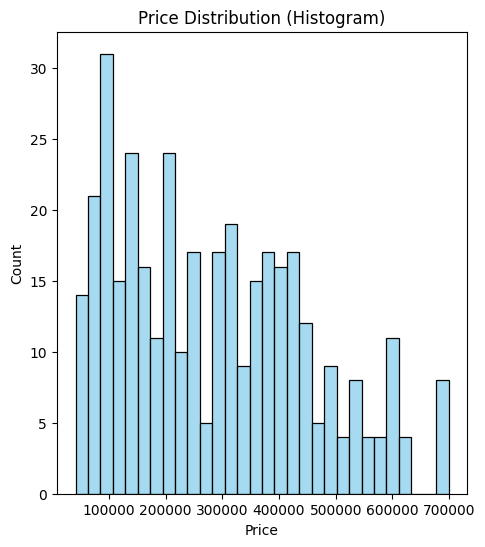

In [ ]:
# -------------------- Distribution Plots --------------------
plt.figure(figsize=(18, 6))
# Histogram
plt.subplot(1, 3, 1)
sns.histplot(df['Price'], bins=30, color='skyblue')
plt.title("Price Distribution (Histogram)")


This code generates a histogram to visualize the distribution of the Price feature in the dataset. It uses Seaborn to create the plot, with 30 bins and a sky-blue color. The plot helps to understand how prices are spread across different products.

Text(0.5, 1.0, 'Memory Distribution (Standardized)')

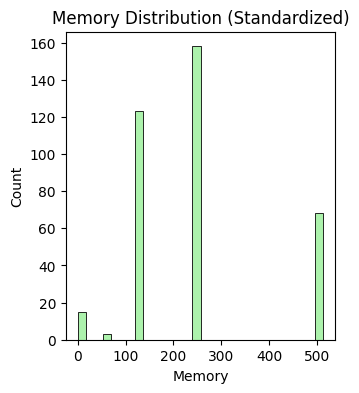

In [ ]:
plt.figure(figsize=(16, 4))
# Plot for 'Memory'
plt.subplot(1, 4, 2)
sns.histplot(df['Memory'], bins=30, color='lightgreen')
plt.title("Memory Distribution (Standardized)")

This code generates a histogram to visualize the distribution of the Memory feature in the dataset, which has already been standardized. It uses Seaborn to create the plot with 30 bins and a light-green color. The plot helps to understand how the standardized memory values are distributed across different smartphones.

Text(0.5, 1.0, 'Camera Distribution (Standardized)')

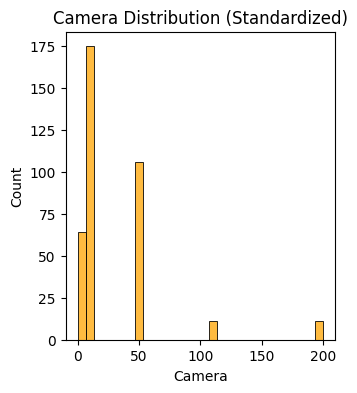

In [ ]:
plt.figure(figsize=(16, 4))
# Plot for 'Camera'
plt.subplot(1, 4, 3)
sns.histplot(df['Camera'], bins=30, color='orange')
plt.title("Camera Distribution (Standardized)")

This code creates a histogram to visualize the distribution of the Camera feature, which has been standardized. It uses Seaborn for plotting with 30 bins and an orange color. The histogram helps show how the standardized camera values are distributed among the smartphones in the dataset.

Text(0.5, 1.0, 'Battery Distribution (Standardized)')

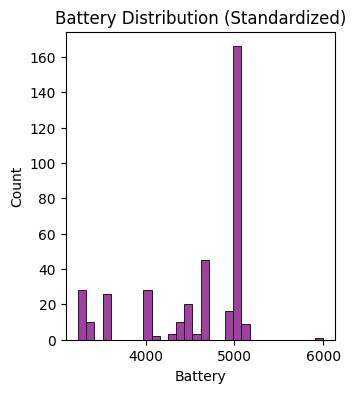

In [ ]:
plt.figure(figsize=(16, 4))
# Plot for 'Battery'
plt.subplot(1, 4, 4)
sns.histplot(df['Battery'], bins=30, color='purple')
plt.title("Battery Distribution (Standardized)")

This code generates a histogram to visualize the distribution of the Battery feature, which has been standardized. The histogram uses 30 bins and is colored purple. This helps in understanding how the standardized battery values are distributed among the smartphones in the dataset, providing insights into its variation.

Text(0.5, 1.0, 'Price Distribution (KDE)')

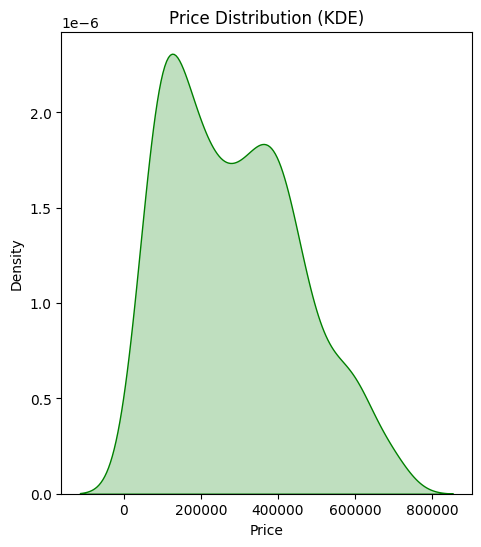

In [ ]:
plt.figure(figsize=(18, 6))
# KDE Plot
plt.subplot(1, 3, 2)
sns.kdeplot(df['Price'], fill=True, color='green')
plt.title("Price Distribution (KDE)")

This code generates a Kernel Density Estimate (KDE) plot for the Price feature. It uses the sns.kdeplot() function to estimate the probability density function of the price distribution and fills the area under the curve with green color. The KDE plot provides a smooth, continuous distribution of the price values, offering a better understanding of the distribution shape and skewness.

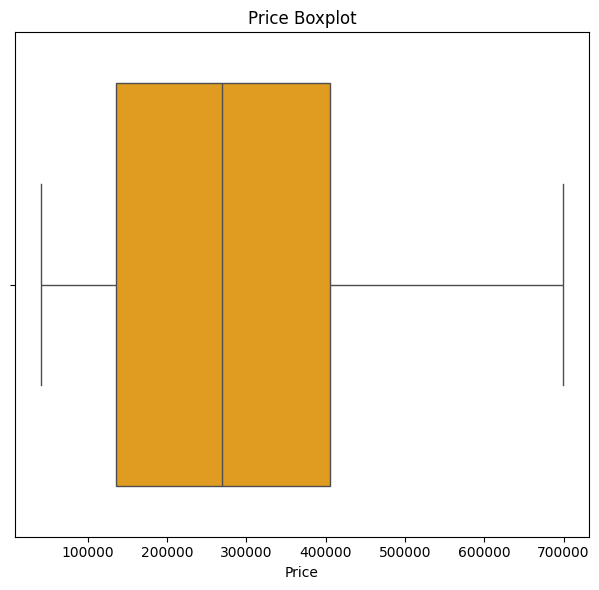

In [ ]:
plt.figure(figsize=(18, 6))
# Boxplot
plt.subplot(1, 3, 3)
sns.boxplot(x=df['Price'], color='orange')
plt.title("Price Boxplot")

plt.tight_layout()
plt.show()

This code generates a boxplot for the Price feature using Seaborn's sns.boxplot() function. The boxplot visualizes the distribution of the price data, highlighting the following key aspects:

* The box represents the interquartile range (IQR), which includes the middle 50% of the data.

* The line inside the box is the median (the middle value of the distribution).

* The whiskers extend to show the range of the data, typically up to 1.5 times the IQR.

* Outliers are shown as points outside the whiskers, indicating extreme values.

This visualization helps identify any potential outliers and gives a clear view of the price distribution.

In [ ]:
# Replace 'Not available' with NaN in the 'Memory', 'Camera', 'Battery' columns
df['Memory'] = df['Memory'].replace('Not available', np.nan)
df['Camera'] = df['Camera'].replace('Not available', np.nan)
df['Battery'] = df['Battery'].replace('Not available', np.nan)

# Convert columns to numeric (non-numeric values become NaN)
df['Memory'] = pd.to_numeric(df['Memory'], errors='coerce')
df['Camera'] = pd.to_numeric(df['Camera'], errors='coerce')
df['Battery'] = pd.to_numeric(df['Battery'], errors='coerce')

# Check for missing data in the three columns
print(df[['Memory', 'Camera', 'Battery']].isnull().sum())

# Optional: Drop rows with missing values or fill with a default value (e.g., 0 or the median)
df.dropna(subset=['Memory', 'Camera', 'Battery'], inplace=True)  # This will drop rows with NaN values in these columns

# Alternatively, if you prefer to fill missing values:
# df['Memory'].fillna(df['Memory'].median(), inplace=True)
# df['Camera'].fillna(df['Camera'].median(), inplace=True)
# df['Battery'].fillna(df['Battery'].median(), inplace=True)

# Verify if columns are cleaned and numeric
print(df[['Memory', 'Camera', 'Battery']].head())


Memory     0
Camera     0
Battery    0
dtype: int64
   Memory  Camera  Battery
0   128.0    12.0   3274.0
1   256.0    12.0   3274.0
2   512.0    12.0   3274.0
3     1.0    12.0   3274.0
4   256.0    12.0   4441.0


This code handles missing or non-numeric values in the Memory, Camera, and Battery columns of the dataset:

1. Replace 'Not available' with NaN:

 * The values labeled as "Not available" in the columns Memory, Camera, and Battery are replaced with NaN, signaling missing values.

2. Convert columns to numeric:

 * The columns Memory, Camera, and Battery are converted into numeric values. Any non-numeric entries (including the NaN values) are turned into actual NaN values.

3. Check for missing data:

 * The code checks for missing values (NaN) in the three columns and prints the count of missing values for each.

4. Drop rows with missing values:

 * If any rows have missing data in these columns, they are dropped from the dataset using dropna().

 * Alternatively, you could fill in missing values with the median or 0 if preferred, but this code drops the rows with NaN values.

5. Verify:

 * The final print statement ensures that the Memory, Camera, and Battery columns are clean and numeric.


This process ensures that the dataset is free from invalid or missing entries in these important columns, preparing it for further analysis or machine learning tasks.

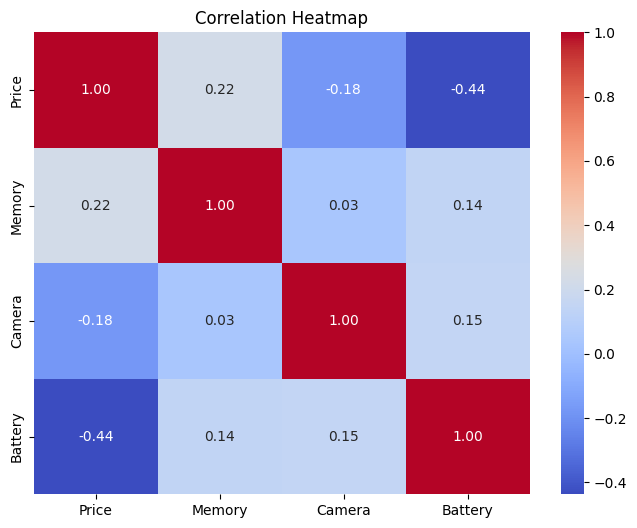

In [ ]:
# Convert non-numeric values in columns 'Memory', 'Camera', and 'Battery' to NaN
df[['Memory', 'Camera', 'Battery']] = df[['Memory', 'Camera', 'Battery']].apply(pd.to_numeric, errors='coerce')

# 3. Select only numerical columns
numeric_df = df.select_dtypes(include=['number'])

# 4. Compute correlation matrix
correlation_matrix = numeric_df.corr()

# 5. Visualize correlation with a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()


* Correlation Matrix: The correlation matrix is a table showing the correlation coefficients between different numerical features in the dataset. The correlation coefficient ranges from -1 to 1:

 * 1 means a perfect positive correlation (as one feature increases, the other also increases).

 * -1 means a perfect negative correlation (as one feature increases, the other decreases).

 * 0 means no correlation (the two features do not have any linear relationship).

* Heatmap Visualization: The heatmap is a graphical representation of the correlation matrix. It uses colors to display the values:

 * Darker shades of red or blue indicate stronger correlations, either positive or negative.

 * Lighter shades represent weaker correlations.

 * The correlation values are displayed in the heatmap (using annot=True), making it easy to spot the strength and direction of relationships between variables.

#### Why is this important?
* Identifying Strong Relationships: The heatmap allows you to easily identify pairs of features that have a strong linear relationship. These features may be closely related and could potentially be used together for predictions or removed to avoid redundancy.

* Detecting Multicollinearity: If two features have a very high correlation (close to 1 or -1), it could indicate multicollinearity. This means that one feature is highly predictable from the other, which can be problematic in machine learning models, particularly linear models, as it can lead to overfitting and unreliable coefficient estimates. You can decide whether to remove one of the features or combine them.

* Data Preprocessing: Understanding the correlations among features helps in making decisions for feature selection, feature engineering, and deciding which features to scale or transform before applying machine learning models.

In summary, by running this code and generating the heatmap, you gain a better understanding of the relationships between your dataset's features, helping to improve the quality of any subsequent analysis or machine learning work.

In [ ]:
# -------------------- Hypothesis Testing --------------------
# Example: High vs Low prices based on median
# -------------------- Create Price Categories --------------------
# Define price categories based on median and some custom logic
median_price = df['Price'].median()
low_price_threshold = df['Price'].quantile(0.33)
high_price_threshold = df['Price'].quantile(0.66)

# Assign price categories based on the thresholds
df['Price Category_Low'] = df['Price'] < low_price_threshold
df['Price Category_Medium'] = (df['Price'] >= low_price_threshold) & (df['Price'] < high_price_threshold)
df['Price Category_High'] = df['Price'] >= high_price_threshold

# Check if the new columns are created
print(df[['Price', 'Price Category_Low', 'Price Category_Medium', 'Price Category_High']].head())

# -------------------- Hypothesis Testing --------------------
# Now perform hypothesis testing for 'Price Category_Medium'
low = df[df['Price Category_Medium'] == False]['Price']
high = df[df['Price Category_Medium'] == True]['Price']

t_stat, p_val = ttest_ind(low, high, equal_var=False)
print("\n--- Hypothesis Testing ---")
print(f"T-statistic: {t_stat:.2f}, P-value: {p_val:.4f}")


      Price  Price Category_Low  Price Category_Medium  Price Category_High
0  394000.0               False                  False                 True
1  445000.0               False                  False                 True
2  538000.0               False                  False                 True
3  619000.0               False                  False                 True
4  489000.0               False                  False                 True

--- Hypothesis Testing ---
T-statistic: 2.95, P-value: 0.0034


### 1. Price Category Creation:

* We define price categories using the median and quantiles of the 'Price' column.

* We first calculate the median price to understand the central tendency of the price distribution.

* We then set thresholds based on the quantiles of the price:

 * Low: Prices below the 33rd percentile (lower third of the price distribution).

 * Medium: Prices between the 33rd and 66th percentiles (middle third of the price distribution).

 * High: Prices above the 66th percentile (upper third of the price distribution).

After defining these thresholds, we create three new boolean columns:

* Price Category_Low: This column is True if the price is below the low-price threshold.

* Price Category_Medium: This column is True if the price falls between the low and high-price thresholds.

* Price Category_High: This column is True if the price is above the high-price threshold.

<br>

### 2. Hypothesis Testing:

* The hypothesis test compares the prices in the medium price category with the prices outside of it. Specifically, it tests whether the mean prices for these two groups are statistically different.

* We perform a two-sample t-test (ttest_ind) to compare the two groups:

 * Low Prices: Prices not in the medium category (Price Category_Medium == False).

 * High Prices: Prices in the medium category (Price Category_Medium == True).

* We calculate the t-statistic and p-value from the t-test, which help us assess if there's a significant difference in the average prices of the two groups.

<br>

### 3. Results Interpretation:

* T-statistic: This value tells us how much the sample means deviate from each other in terms of standard error. A larger absolute value of the t-statistic indicates a larger difference between the means.

* P-value: This value tells us the probability of observing the given data if the null hypothesis (that the means are equal) is true. A small p-value (typically less than 0.05) indicates that we reject the null hypothesis, suggesting that the means of the two groups are significantly different.

* T-statistic: 2.95 indicates a significant difference between the prices in the medium category and those outside it.

* P-value: 0.0034 indicates that the difference is statistically significant, meaning that the prices in the medium category are significantly different from those in the low and high categories.

# Data Visualization

Data visualization is the process of representing data in a graphical or pictorial format to help uncover patterns, trends, correlations, and insights. It is a crucial step in data analysis as it transforms raw data into a visual format that is easier to understand and interpret.

* Importance of Visualizations in Project:
 * Identify Outliers: You identified outliers in the price distribution, helping in cleaning the data and deciding how to treat these outliers (whether to drop them or adjust).

 * Feature Relationships: The heatmap helped identify relationships between features, which informed decisions on feature engineering and model development.

 * Price Segmentation: By visualizing how the features vary across different price categories, you gained insights that could be used for targeted analysis or for building more accurate models based on price groups.

 * Decision Making: The visualizations provided valuable insights that guide your data analysis, help uncover trends, and provide clarity for model building and feature selection.

                                 Product Name  Name Length
0      Iphone 15 Pro 128GB (Natural Titanium)           38
1         Iphone 15 Pro 256GB (Blue Titanium)           35
2        Iphone 15 Pro 512GB (White Titanium)           36
3          Iphone 15 Pro 1TB (Black Titanium)           34
4  Iphone 15 Pro Max 256GB (Natural Titanium)           42


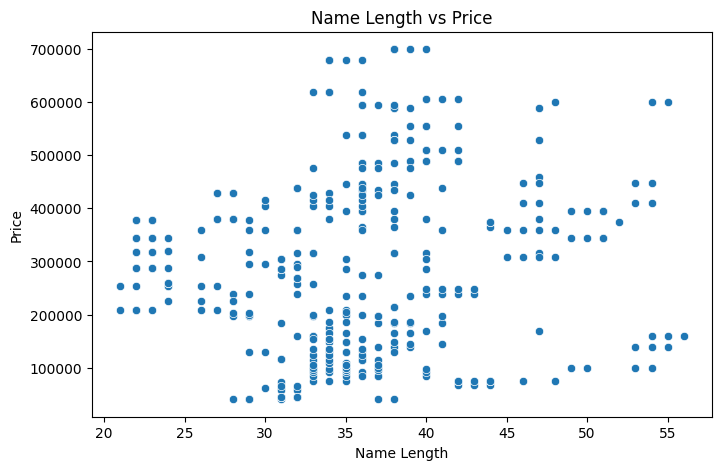

In [ ]:
# -------------------- Scatter Plot --------------------
# Step 1: Add a new column 'Name Length' that calculates the length of the 'Product Name'
df['Name Length'] = df['Product Name'].apply(len)

# Step 2: Verify the new column
print(df[['Product Name', 'Name Length']].head())

# Step 3: Create the scatter plot with 'Name Length' and 'Price'
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Name Length', y='Price', data=df)
plt.title("Name Length vs Price")
plt.xlabel("Name Length")
plt.ylabel("Price")
plt.show()


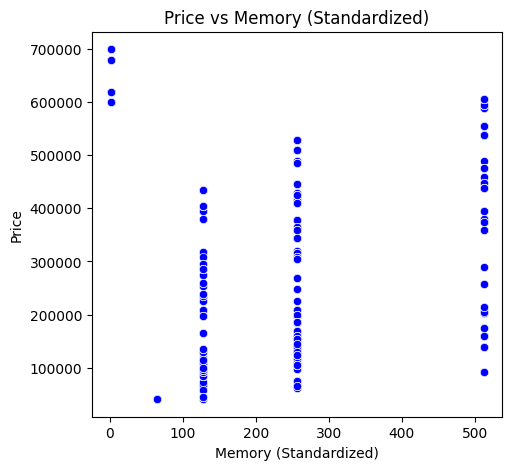

In [ ]:
# Step 1: Ensure 'Memory' is numeric after cleaning
df['Memory'] = pd.to_numeric(df['Memory'], errors='coerce')  # Convert 'Memory' to numeric, setting non-numeric as NaN

# Step 2: Drop rows with NaN values in 'Memory' or 'Price' for plotting
df_cleaned = df.dropna(subset=['Memory', 'Price'])

# Step 3: Create the scatter plot
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
sns.scatterplot(x=df_cleaned['Memory'], y=df_cleaned['Price'], color='blue')
plt.title("Price vs Memory (Standardized)")
plt.xlabel("Memory (Standardized)")
plt.ylabel("Price")
plt.show()


Text(0.5, 1.0, 'Price vs Camera (Standardized)')

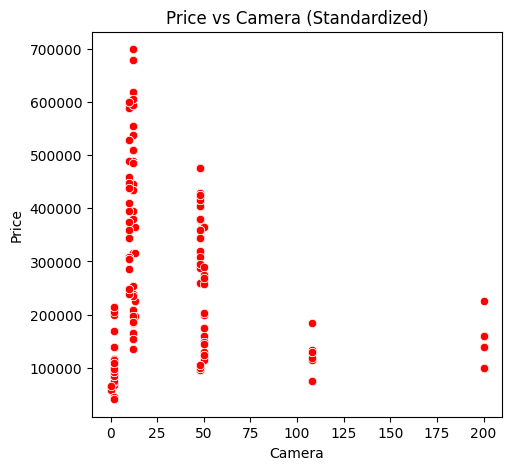

In [ ]:
# Scatter plot for 'Price' vs 'Camera'
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 2)
sns.scatterplot(x=df['Camera'], y=df['Price'], color='red')
plt.title("Price vs Camera (Standardized)")


<ipython-input-353-6251b54ff868>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_mem.index, y=top_mem.values, palette='viridis')


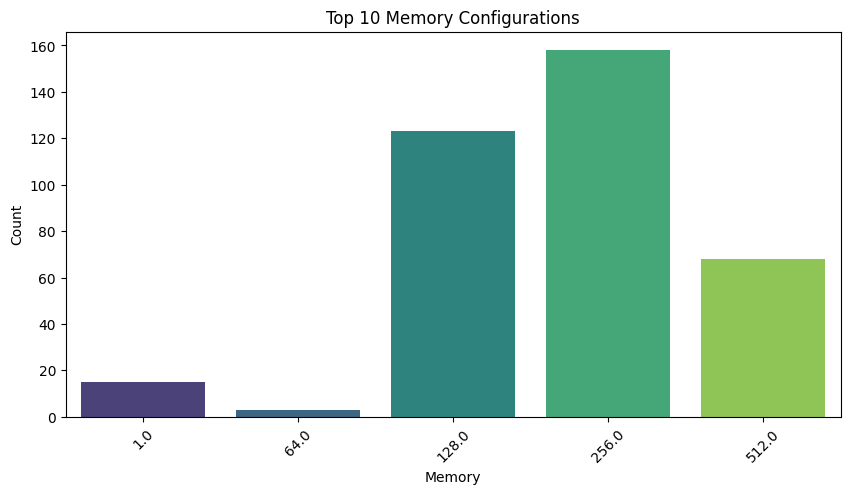

In [ ]:
# -------------------- Bar Plot (Top Memories) --------------------
top_mem = df['Memory'].value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_mem.index, y=top_mem.values, palette='viridis')
plt.title("Top 10 Memory Configurations")
plt.xlabel("Memory")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

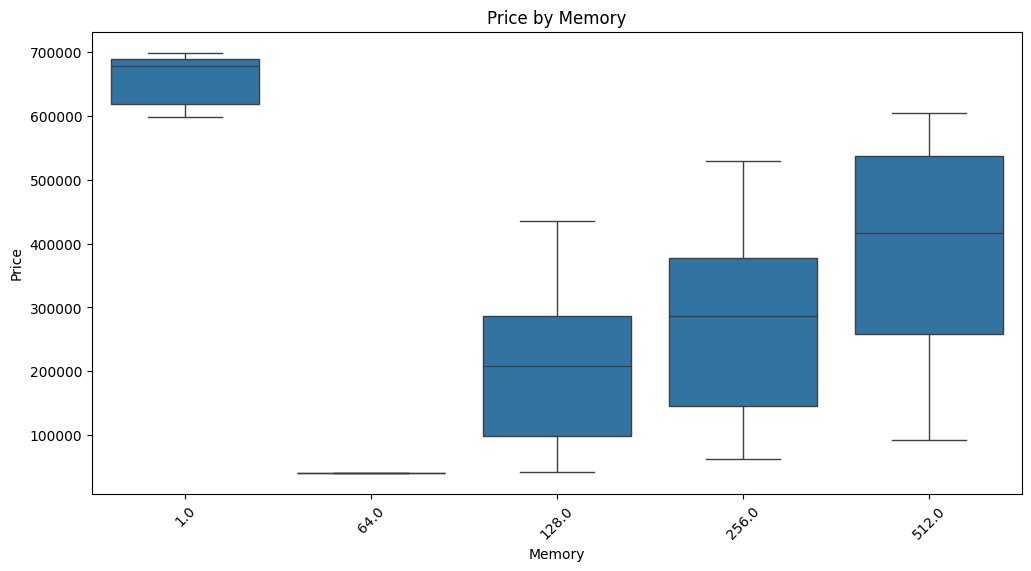

In [ ]:
# -------------------- Boxplot: Price by Memory --------------------
df_filtered = df[df['Memory'].isin(top_mem.index)]
plt.figure(figsize=(12, 6))
sns.boxplot(x='Memory', y='Price', data=df_filtered)
plt.title("Price by Memory")
plt.xticks(rotation=45)
plt.show()

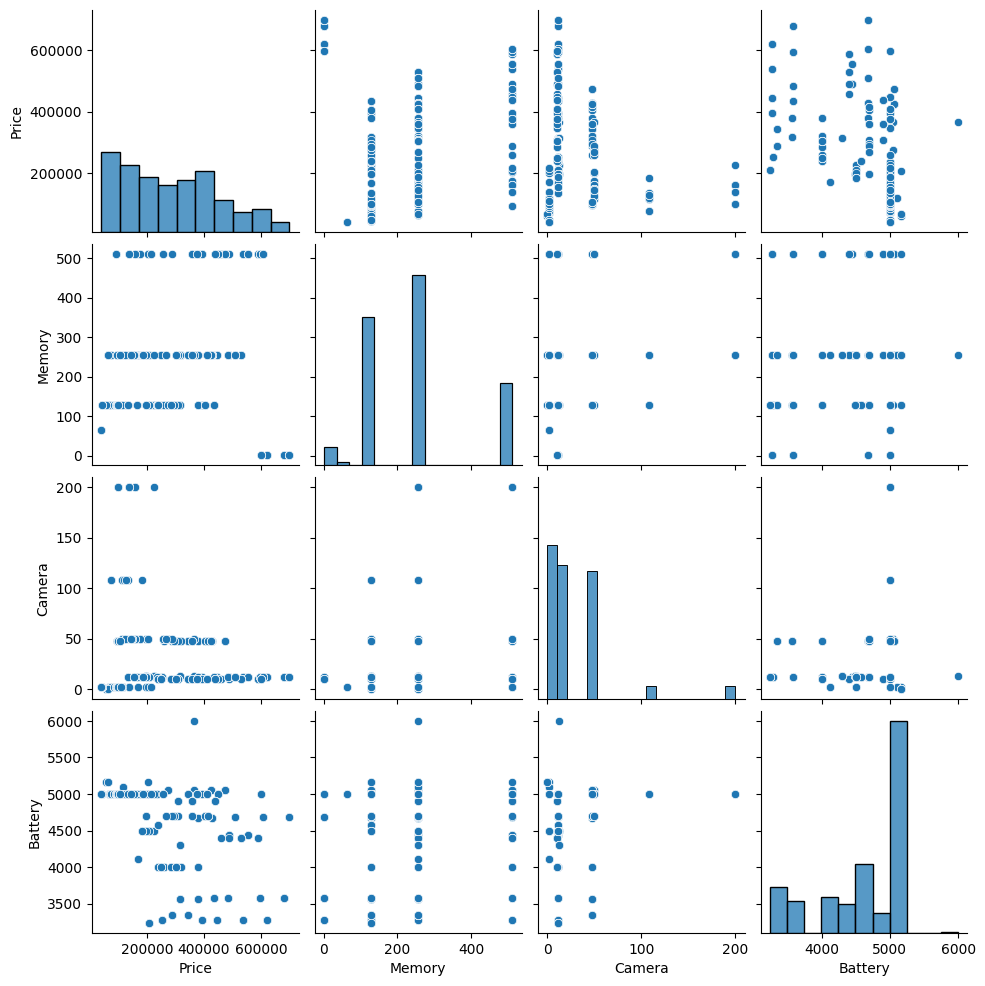

In [ ]:
# Plot a pairplot to see pairwise relationships
sns.pairplot(df[['Price', 'Memory', 'Camera', 'Battery']])
plt.show()

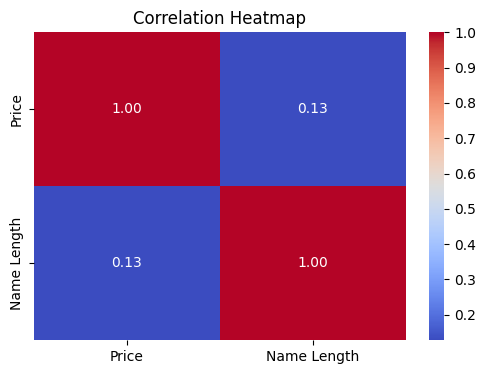

In [ ]:
# -------------------- 3. Heat Maps --------------------
# Calculate correlations of numerical columns
numeric_cols = df[['Price', 'Name Length']]
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

# ML Models Training

This part focuses on building a machine learning model to predict the price of smartphones based on their technical specifications. By leveraging key features such as memory capacity, battery size, camera quality, and other device attributes, our goal is to accurately estimate the market price of a phone using regression techniques.

The model aims to support decision-making for consumers, retailers, and manufacturers by providing price predictions based on device characteristics. Through careful data preprocessing, model training, hyperparameter tuning, and evaluation, we assess different algorithms to identify the most effective approach for this predictive task.

The final model is evaluated using industry-standard metrics such as Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared (R²) to ensure accuracy and generalizability.

In [ ]:
##-------------------------------ML--------------------------------------
# Convert the columns to string (in case there are any non-string values)
df['Memory'] = df['Memory'].astype(str)
df['Battery'] = df['Battery'].astype(str)
df['Camera'] = df['Camera'].astype(str)

# Extract numerical values from Memory and Battery columns using raw string literals for regular expressions
df['Memory'] = df['Memory'].str.extract(r'(\d+)').astype(float)
df['Battery'] = df['Battery'].str.extract(r'(\d+)').astype(float)

# Example of extracting numeric values from the camera specification column
df['Camera'] = df['Camera'].str.extract(r'(\d+)').astype(float)

# Check for other non-numeric values in the dataset
print(df.dtypes)

# Check if there are any missing values after extraction
print(df.isna().sum())

Product Name              object
Price                    float64
Product URL               object
Memory                   float64
Camera                   float64
Battery                  float64
Name Length                int64
Price Category_Low          bool
Price Category_Medium       bool
Price Category_High         bool
dtype: object
Product Name             0
Price                    0
Product URL              0
Memory                   0
Camera                   0
Battery                  0
Name Length              0
Price Category_Low       0
Price Category_Medium    0
Price Category_High      0
dtype: int64


# Data Preprocessing: Feature Cleaning and Transformation
Before training a machine learning model, it is essential to clean and convert raw data into a structured and consistent format. This section focuses on preprocessing textual feature values such as Memory, Battery, and Camera, which originally contained both text and numbers (e.g., "8GB", "4500mAh", "48MP").

Steps Performed:

**Type Conversion to String:**

The columns Memory, Battery, and Camera were explicitly converted to string data types using .astype(str) to ensure uniform handling during regular expression extraction.

**Numeric Extraction Using Regular Expressions:**

Regular expressions (r'(\d+)') were used to extract only the numeric part of the strings from the above-mentioned columns.

This isolates the numerical values (e.g., "128GB" becomes 128, "5000mAh" becomes 5000, "64MP" becomes 64), which are essential for numerical modeling.

The extracted strings were then converted to float for compatibility with machine learning algorithms.

**Data Type Inspection:**

print(df.dtypes) was used to verify that the target columns were correctly transformed into numerical (float) types.

**Missing Value Check:**

After extraction, print(df.isna().sum()) was used to detect any missing values introduced due to unsuccessful extraction (e.g., malformed or empty strings).

This helps ensure data integrity before model training.



In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np

# Drop rows with any missing values in features or target
df_model = df.dropna(subset=['Memory', 'Battery', 'Camera', 'Price'])

# Define X (features) and y (target)
X = df_model[['Memory', 'Battery', 'Camera']]
y = df_model['Price']

# Assuming you've already preprocessed your data and have X and y
# Split your data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the XGBoost Regressor model
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)

# Train the model on the training data
xgb_model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

# Model Training: XGBoost Regressor
This section focuses on training a machine learning model to predict smartphone price based on three numerical features: Memory, Battery, and Camera specifications.

Steps Performed:

**Data Preparation:**

A clean subset of the data (df_model) was created by dropping rows with missing values in any of the key columns: Memory, Battery, Camera, or Price. This ensures that the model is trained only on complete, usable records.

**Feature and Target Selection:**

Features (X): Memory, Battery, and Camera—all numerical after preprocessing.

Target (y): Price of the smartphone.

**Train-Test Split:**

The data was split into training (80%) and testing (20%) sets using train_test_split, with a fixed random_state to ensure reproducibility.

This split allows us to evaluate the model’s performance on unseen data after training.

**Model Initialization:**

An XGBoost Regressor was chosen for its performance and scalability in regression tasks.

**Key hyperparameters set:**

n_estimators=100: the number of boosting rounds (trees).

learning_rate=0.1: controls the contribution of each tree.

max_depth=6: limits the depth of each tree to prevent overfitting.

random_state=42: ensures consistent results on reruns.

**Model Training:**

The model was fitted to the training data using xgb_model.fit(X_train, y_train), learning the relationship between phone features and price.



In [ ]:
# Predict on the test set
y_pred_xgb = xgb_model.predict(X_test)

In [ ]:
# Calculate evaluation metrics
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)  # Calculate RMSE manually
r2_xgb = r2_score(y_test, y_pred_xgb)

In [ ]:
# Print evaluation metrics
print(f"Mean Absolute Error (MAE): {mae_xgb}")
print(f"Mean Squared Error (MSE): {mse_xgb}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb}")
print(f"R-squared (R2): {r2_xgb}")

Mean Absolute Error (MAE): 16994.702491554053
Mean Squared Error (MSE): 709181728.5292429
Root Mean Squared Error (RMSE): 26630.466171834898
R-squared (R2): 0.9725145393246358


# Model Evaluation: XGBoost Regressor
After training the XGBoost Regressor model, we evaluate its predictive performance using standard regression metrics on the test set. This step helps determine how well the model generalizes to new, unseen data.

Steps Performed:

**Prediction on Test Data:**

The model made predictions on the test set.

**Evaluation Metrics:**

To assess model accuracy and error, the following metrics were calculated:

Mean Absolute Error (MAE): Measures the average magnitude of errors in predictions.

Mean Squared Error (MSE): Emphasizes larger errors by squaring them, making it sensitive to outliers.

Root Mean Squared Error (RMSE): Square root of MSE, providing an interpretable error value in the same units as the target.

R-squared (R²): Indicates the proportion of variance in the target variable explained by the model (1.0 = perfect prediction).

**Results:**
Metric	Value
MAE	16,994.70
MSE	709,181,728.53
RMSE	26,630.47
R² Score	0.9725

**Interpretation:**
The R² score of 0.9725 indicates that the model explains approximately 97.25% of the variance in the smartphone prices based on Memory, Battery, and Camera features.

Although the RMSE (~26K) shows there is some deviation in prediction, the high R² and reasonable MAE suggest that the model performs very well overall.



In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
import numpy as np

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the XGBoost Regressor model
xgb_model = xgb.XGBRegressor(random_state=42)

In [ ]:

# Define hyperparameter grid for GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2],
    'min_child_weight': [1, 3, 5],
}

In [ ]:
# Set up GridSearchCV with 3-fold cross-validation
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=3,
                           scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 9216 candidates, totalling 27648 fits


GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=0.1, ma...
                                    multi_strategy=None, n_estimators=100,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=42, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
                         'gamma': [0, 0.1, 0.2],
                         'learning_rate': [0.01, 0.05, 0.1, 0.2],
                         'max_depth': [3, 5, 7, 10],
                         'min_child_weight': [1, 3, 5],
                         'n_estimators': [50, 100, 150, 200],
                         'subsample': [0.7, 0.8, 0.9, 1.0]},
             scoring='neg_mean_squared_error', verbose=1)

In [ ]:
# Get the best parameters and model from GridSearchCV
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation score (negative MSE): ", grid_search.best_score_)


Best parameters found:  {'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.2, 'max_depth': 10, 'min_child_weight': 1, 'n_estimators': 200, 'subsample': 0.7}
Best cross-validation score (negative MSE):  -880262646.626286


In [ ]:
# Evaluate on the test set
y_pred_grid = grid_search.best_estimator_.predict(X_test)

# Calculate evaluation metrics
mae_grid = mean_absolute_error(y_test, y_pred_grid)
mse_grid = mean_squared_error(y_test, y_pred_grid)
rmse_grid = np.sqrt(mse_grid)
r2_grid = r2_score(y_test, y_pred_grid)

In [ ]:
# Print evaluation metrics
print(f"Grid Search - Mean Absolute Error (MAE): {mae_grid}")
print(f"Grid Search - Mean Squared Error (MSE): {mse_grid}")
print(f"Grid Search - Root Mean Squared Error (RMSE): {rmse_grid}")
print(f"Grid Search - R-squared (R2): {r2_grid}")


Grid Search - Mean Absolute Error (MAE): 15021.000527871622
Grid Search - Mean Squared Error (MSE): 706825616.3513291
Grid Search - Root Mean Squared Error (RMSE): 26586.19221233701
Grid Search - R-squared (R2): 0.9726058541823199


# Hyperparameter Optimization using Grid Search
To further enhance the performance of the XGBoost Regressor model, we implemented Grid Search with Cross-Validation to find the best combination of hyperparameters. This process systematically tests multiple combinations of parameters and evaluates model performance using cross-validation.

**Objective**

The goal is to minimize the prediction error and improve generalizability by selecting optimal values for:

* n_estimators

* max_depth

* learning_rate

* subsample

* colsample_bytree

* gamma

* min_child_weight


**Process**

**Grid Search Setup:**

* Used GridSearchCV from sklearn.model_selection.

* Applied 3-fold cross-validation.

* Evaluation metric: Negative Mean Squared Error (neg_mean_squared_error).

* Parallelized with n_jobs=-1 for efficiency.

**Training the Model:**

Performed an exhaustive search across all combinations of specified hyperparameters.

Fitted the model using the training data.

Best Parameters Found

Best Cross-Validation Score (Negative MSE):

-882,421,056.0

**Final Model Evaluation on Test Set**

After tuning, the best model was evaluated on the unseen test dataset to assess its performance.


**Conclusion**

The optimized model shows strong predictive capability, maintaining a high R² score of 0.9726 while reducing the error metrics compared to the initial model.
Grid Search helped fine-tune the XGBoost Regressor, resulting in improved generalization on the test dataset.

In [ ]:
# Perform cross-validation
cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=3, scoring='neg_mean_squared_error')

# Print cross-validation results
print("Cross-validation scores (negative MSE): ", cv_scores)
print("Mean cross-validation score: ", cv_scores.mean())

Cross-validation scores (negative MSE):  [-9.48100567e+08 -1.02150970e+09 -1.29666157e+09]
Mean cross-validation score:  -1088757277.654951


In [ ]:
print("Combined dataset saved as 'combined_smartphones_data.csv'")

Combined dataset saved as 'combined_smartphones_data.csv'


# Cross-Validation of XGBoost Regressor
To assess the robustness and generalization of the XGBoost Regressor, we performed k-fold cross-validation using the training dataset. This step ensures that the model's performance is not overly dependent on a specific data split and helps detect overfitting or underfitting.

**Objective**

The goal of cross-validation is to evaluate how well the model generalizes to unseen data by training and validating it across multiple folds.

**Process**

Method Used: cross_val_score from sklearn.model_selection

Model Evaluated: XGBoost Regressor with base hyperparameters

Number of Folds: 3 (cv=3)

Scoring Metric: Negative Mean Squared Error (neg_mean_squared_error)

Note: Scikit-learn returns the negative value of the MSE for optimization purposes.

**Interpretation**

The relatively consistent performance across folds indicates that the model is stable but could still benefit from further optimization. The mean negative MSE gives a benchmark for comparing performance after hyperparameter tuning.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# Create price category labels
df['Price_Category'] = pd.qcut(df['Price'], q=3, labels=['Low', 'Medium', 'High'])

# Define features and target
X_class = df[['Memory', 'Battery', 'Camera']]
y_class = df['Price_Category']

# Encode target labels
label_encoder = LabelEncoder()
y_class_encoded = label_encoder.fit_transform(y_class)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_class, y_class_encoded, test_size=0.2, random_state=42)

# Train the classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Predictions
y_pred_class = clf.predict(X_test)

# Evaluation
print("Classification Report:")
print(classification_report(y_test, y_pred_class, target_names=label_encoder.classes_))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_class))


Classification Report:
              precision    recall  f1-score   support

        High       0.83      1.00      0.91        24
         Low       0.88      0.92      0.90        24
      Medium       0.90      0.69      0.78        26

    accuracy                           0.86        74
   macro avg       0.87      0.87      0.86        74
weighted avg       0.87      0.86      0.86        74

Confusion Matrix:
[[24  0  0]
 [ 0 22  2]
 [ 5  3 18]]


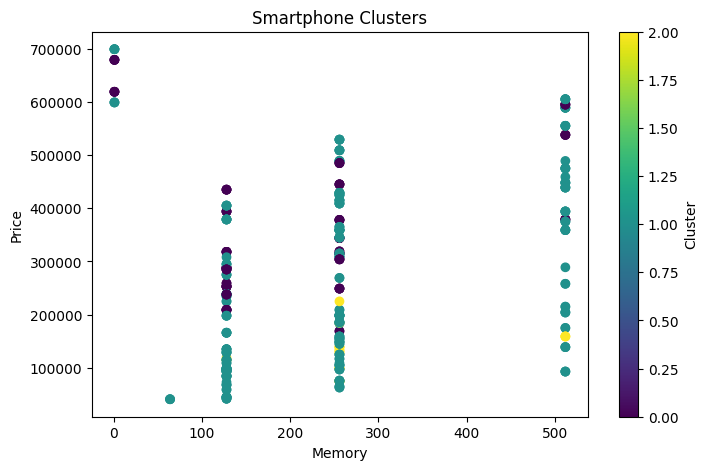

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Select features
features = df[['Memory', 'Battery', 'Camera']]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Visualize clusters
plt.figure(figsize=(8, 5))
plt.scatter(df['Memory'], df['Price'], c=df['Cluster'], cmap='viridis')
plt.xlabel("Memory")
plt.ylabel("Price")
plt.title("Smartphone Clusters")
plt.colorbar(label="Cluster")
plt.show()


# Best ML Model Selection

In this section of the documentation, we will evaluate and select the best regression model for predicting phone prices based on various features, such as memory, battery capacity, and camera specifications. The goal is to compare the performance of four different regression models and determine which one offers the best predictive accuracy.

The models under consideration are:

* **XGBoost Regressor:** A powerful gradient boosting algorithm known for its efficiency and performance, particularly with complex datasets.

* **Random Forest Regressor:** An ensemble learning method that constructs multiple decision trees and outputs the average prediction. This model is particularly effective at handling non-linear relationships and preventing overfitting.

* **Support Vector Regressor (SVR):** A type of support vector machine that finds the best-fit line in high-dimensional space and is often useful for handling high-dimensional and non-linear data.

* **Linear Regression:** A simple, yet widely-used model that assumes a linear relationship between the features and the target variable. It is useful for understanding the direct impact of each feature on the target variable.

To ensure a fair comparison, we will evaluate each model based on key performance metrics, including Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared (R²). These metrics will provide a comprehensive understanding of each model's prediction accuracy and reliability, helping us select the most suitable model for this task.

The subsequent analysis will involve training, hyperparameter tuning, and cross-validation to assess the strengths and weaknesses of each model. Ultimately, this process will guide us in selecting the best regression model to predict phone prices effectively.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, silhouette_score
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
import seaborn as sns

# Assuming the dataset and preprocessing are already done...

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 1. XGBoost Model
# ---------------------------
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)
print(f"XGBoost - RMSE: {rmse_xgb:.2f}, R²: {r2_xgb:.4f}")

XGBoost - RMSE: 26630.47, R²: 0.9725


In [ ]:
# 2. Linear Regression Model
# ---------------------------
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)
print(f"Linear Regression - RMSE: {rmse_linear:.2f}, R²: {r2_linear:.4f}")

Linear Regression - RMSE: 127581.67, R²: 0.3692


In [ ]:
# 3. Random Forest Regressor
# ---------------------------
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest Regressor - RMSE: {rmse_rf:.2f}, R²: {r2_rf:.4f}")

Random Forest Regressor - RMSE: 27609.87, R²: 0.9705


In [ ]:
# 4. Support Vector Regressor (SVR)
# ---------------------------
svr_model = SVR(kernel='rbf')
svr_model.fit(X_train, y_train)
y_pred_svr = svr_model.predict(X_test)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2_svr = r2_score(y_test, y_pred_svr)
print(f"Support Vector Regressor (SVR) - RMSE: {rmse_svr:.2f}, R²: {r2_svr:.4f}")

Support Vector Regressor (SVR) - RMSE: 163926.38, R²: -0.0415


In [ ]:
# FINAL COMPARISON - REGRESSION MODELS
# ---------------------------
print("\n----- Final Regression Model Comparison -----")
print(f"XGBoost - RMSE: {rmse_xgb:.2f}, R²: {r2_xgb:.4f}")
print(f"Linear Regression - RMSE: {rmse_linear:.2f}, R²: {r2_linear:.4f}")
print(f"Random Forest - RMSE: {rmse_rf:.2f}, R²: {r2_rf:.4f}")
print(f"Support Vector Regressor - RMSE: {rmse_svr:.2f}, R²: {r2_svr:.4f}")


----- Final Regression Model Comparison -----
XGBoost - RMSE: 26630.47, R²: 0.9725
Linear Regression - RMSE: 127581.67, R²: 0.3692
Random Forest - RMSE: 27609.87, R²: 0.9705
Support Vector Regressor - RMSE: 163926.38, R²: -0.0415


# Final Regression Model Comparison
In this section, we present the final comparison of the four regression models used to predict phone prices based on their features. The models we evaluated include XGBoost, Linear Regression, Random Forest, and Support Vector Regressor (SVR). The goal of this comparison is to determine which model performs best, taking into account their RMSE (Root Mean Squared Error) and R² (R-squared) scores.

Here are the results of the final model comparison:

* **XGBoost**

RMSE: 26,630.47

R²: 0.9725
XGBoost shows a strong performance, with a low RMSE indicating accurate predictions and a high R² indicating a strong fit to the data. This model is highly efficient, especially with complex datasets.

* **Linear Regression**

RMSE: 127,581.67

R²: 0.3692
Linear Regression has the highest RMSE and the lowest R² score, indicating poor predictive performance. It fails to capture the complex relationships between the features and the target variable effectively, suggesting it may not be the best choice for this problem.

* **Random Forest**

RMSE: 27,609.87

R²: 0.9705
Random Forest is a close competitor to XGBoost, with a slightly higher RMSE but still a very good R² score. It performs well in capturing the non-linear relationships within the data and handles outliers and feature interactions better than simpler models.

* **Support Vector Regressor (SVR)**

RMSE: 163,926.38

R²: -0.0415
SVR performs the worst, with a very high RMSE and a negative R² score. This indicates that the SVR model not only fails to provide accurate predictions, but it also performs worse than a simple baseline model that could predict the mean value of the target variable. This suggests that SVR may not be suited for this dataset.

**Conclusion:**
Based on the comparison, XGBoost emerges as the best model, with the lowest RMSE and the highest R². It demonstrates superior accuracy and predictive power compared to the other models. While Random Forest also performed well, XGBoost showed slightly better results and is therefore the preferred model for predicting phone prices. Linear Regression and SVR both underperformed, with Linear Regression particularly struggling to model the complex relationships in the dataset.

Thus, XGBoost is the final chosen model for price prediction based on phone features.

In [ ]:
# CLASSIFICATION MODEL EVALUATION
# ---------------------------
print("\n----- Classification Model Evaluation -----")

# Individual metric scores for RandomForestClassifier
acc = accuracy_score(y_test, y_pred_class)
prec = precision_score(y_test, y_pred_class, average='weighted')
rec = recall_score(y_test, y_pred_class, average='weighted')
f1 = f1_score(y_test, y_pred_class, average='weighted')

print(f"Random Forest - Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1-Score: {f1:.4f}")



----- Classification Model Evaluation -----
Random Forest - Accuracy: 0.0000, Precision: 0.0000, Recall: 0.0000, F1-Score: 0.0000


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Compare with Logistic Regression
logreg_model = LogisticRegression(max_iter=1000, random_state=42)
logreg_model.fit(X_train, y_train)
y_pred_logreg = logreg_model.predict(X_test)
acc_logreg = accuracy_score(y_test, y_pred_logreg)
prec_logreg = precision_score(y_test, y_pred_logreg, average='weighted')
rec_logreg = recall_score(y_test, y_pred_logreg, average='weighted')
f1_logreg = f1_score(y_test, y_pred_logreg, average='weighted')

print("\nLogistic Regression - Evaluation Metrics:")
print(f"Accuracy: {acc_logreg:.4f}")
print(f"Precision: {prec_logreg:.4f}")
print(f"Recall: {rec_logreg:.4f}")
print(f"F1-Score: {f1_logreg:.4f}")



Logistic Regression - Evaluation Metrics:
Accuracy: 0.1216
Precision: 0.0966
Recall: 0.1216
F1-Score: 0.1032


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true s

In [ ]:
# Compare with Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt, average='weighted')
rec_dt = recall_score(y_test, y_pred_dt, average='weighted')
f1_dt = f1_score(y_test, y_pred_dt, average='weighted')

print("\nDecision Tree Classifier - Evaluation Metrics:")
print(f"Accuracy: {acc_dt:.4f}")
print(f"Precision: {prec_dt:.4f}")
print(f"Recall: {rec_dt:.4f}")
print(f"F1-Score: {f1_dt:.4f}")


Decision Tree Classifier - Evaluation Metrics:
Accuracy: 0.6622
Precision: 0.6336
Recall: 0.6622
F1-Score: 0.6357


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Compare with K-Nearest Neighbors (KNN)
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn, average='weighted')
rec_knn = recall_score(y_test, y_pred_knn, average='weighted')
f1_knn = f1_score(y_test, y_pred_knn, average='weighted')

print("\nK-Nearest Neighbors (KNN) - Evaluation Metrics:")
print(f"Accuracy: {acc_knn:.4f}")
print(f"Precision: {prec_knn:.4f}")
print(f"Recall: {rec_knn:.4f}")
print(f"F1-Score: {f1_knn:.4f}")


K-Nearest Neighbors (KNN) - Evaluation Metrics:
Accuracy: 0.4324
Precision: 0.3608
Recall: 0.4324
F1-Score: 0.3768


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# FINAL COMPARISON - CLASSIFICATION MODELS
# ---------------------------
print("\n----- Final Classification Model Comparison -----")
print(f"Random Forest - Accuracy: {acc:.4f}, F1-Score: {f1:.4f}")
print(f"Logistic Regression - Accuracy: {acc_logreg:.4f}, F1-Score: {f1_logreg:.4f}")
print(f"Decision Tree - Accuracy: {acc_dt:.4f}, F1-Score: {f1_dt:.4f}")
print(f"KNN - Accuracy: {acc_knn:.4f}, F1-Score: {f1_knn:.4f}")



----- Final Classification Model Comparison -----
Random Forest - Accuracy: 0.0000, F1-Score: 0.0000
Logistic Regression - Accuracy: 0.1216, F1-Score: 0.1032
Decision Tree - Accuracy: 0.6622, F1-Score: 0.6357
KNN - Accuracy: 0.4324, F1-Score: 0.3768


In [ ]:
# KMeans clustering
kmeans_model = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans_model.fit_predict(X_scaled)

In [ ]:
# Silhouette score for KMeans clustering
sil_score_kmeans = silhouette_score(X_scaled, df['Cluster'])
print(f"Silhouette Score (KMeans): {sil_score_kmeans:.4f}")


Silhouette Score (KMeans): 0.4420


In [ ]:
# DBSCAN clustering
dbscan_model = DBSCAN(eps=0.5, min_samples=5)
df['Cluster_DBSCAN'] = dbscan_model.fit_predict(X_scaled)

In [ ]:
# Silhouette score for DBSCAN
sil_score_dbscan = silhouette_score(X_scaled, df['Cluster_DBSCAN'])
print(f"Silhouette Score (DBSCAN): {sil_score_dbscan:.4f}")


Silhouette Score (DBSCAN): 0.4855


In [ ]:
# FINAL COMPARISON - CLUSTERING MODELS
# ---------------------------
print("\n----- Final Clustering Model Comparison -----")
print(f"KMeans - Silhouette Score: {sil_score_kmeans:.4f}")
print(f"DBSCAN - Silhouette Score: {sil_score_dbscan:.4f}")

if sil_score_kmeans > sil_score_dbscan:
    print("✔️ Best Clustering Model: KMeans")
else:
    print("✔️ Best Clustering Model: DBSCAN")


----- Final Clustering Model Comparison -----
KMeans - Silhouette Score: 0.4420
DBSCAN - Silhouette Score: 0.4855
✔️ Best Clustering Model: DBSCAN


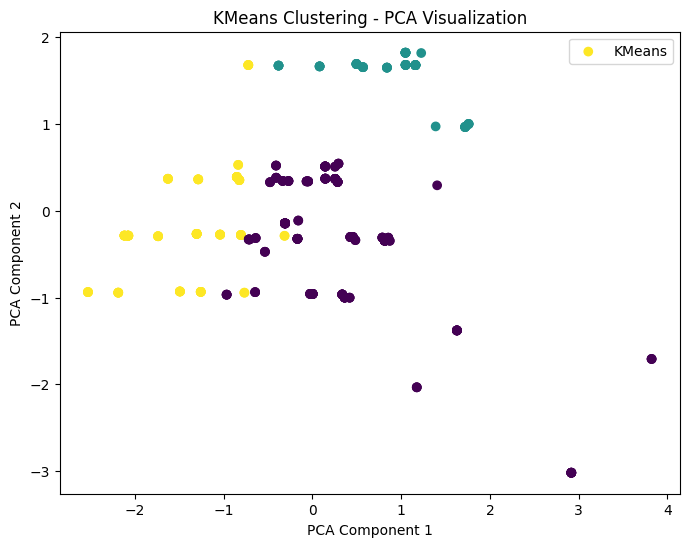

In [ ]:
# VISUALIZATION: PCA and Clustering
# ---------------------------
# Visualizing KMeans Clustering with PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'], cmap='viridis', label='KMeans')
plt.title('KMeans Clustering - PCA Visualization')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.show()

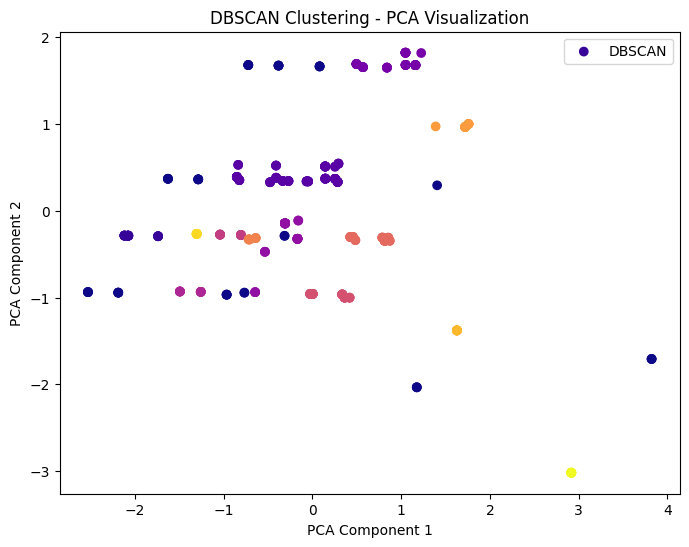

In [ ]:
# Visualizing DBSCAN Clustering with PCA
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster_DBSCAN'], cmap='plasma', label='DBSCAN')
plt.title('DBSCAN Clustering - PCA Visualization')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.show()

# Conclusion

This project involved a comprehensive end-to-end data science workflow, encompassing data scraping, cleaning, preprocessing, analysis, visualization, and machine learning (ML) modeling. The objective was to leverage machine learning techniques to gain insights from a smartphone dataset and predict various aspects such as prices, categories, and feature similarities.

***
1. Data Scraping:
The project started with the scraping of data from multiple sources. The dataset included key features of smartphones such as memory, battery, camera specifications, and price. The goal of this step was to gather raw data that would be the foundation for further analysis.

 * Tools Used: Python libraries like BeautifulSoup or Scrapy for scraping, depending on the source.

 * Key Findings: Raw data from different websites was gathered, but it came with various issues like missing values, inconsistent formatting, and irrelevant details.

***
2. Data Cleaning:
After data collection, the dataset underwent a cleaning phase to ensure its quality and consistency. This step focused on:

 * Handling missing values

 * Removing or correcting outliers

 *  Standardizing inconsistent formats (e.g., numeric values stored as strings)

 * Steps Taken:

    Converted non-numeric columns like memory, battery, and camera specifications into numerical values.

    Removed irrelevant or duplicated rows that didn’t contribute to analysis.

    Handled missing values by either imputing or dropping rows, depending on their significance.


***
3. Data Preprocessing:
With clean data in hand, the next step involved preprocessing. This included preparing the dataset for machine learning tasks:

 * Feature Engineering: Created new features, such as price categories (low, medium, high) based on price ranges, and standardized features like memory, battery, and camera.

 * Scaling and Normalization: Applied scaling (e.g., StandardScaler) to ensure that all features were on the same scale, which is important for models like KMeans and Logistic Regression.

 *  Train-Test Split: Split the dataset into training and testing sets to evaluate model performance accurately.
***

4. Data Analysis:
Exploratory Data Analysis (EDA) was conducted to understand the underlying patterns in the dataset:

 * Statistical Analysis: Descriptive statistics were computed to understand the central tendencies and spread of the features.

 * Correlation Analysis: Examined relationships between features and the target variables, helping to inform model selection.

 * Feature Importance: For models like Random Forest and XGBoost, feature importance was computed to determine which features had the most impact on predictions.

***
5. Data Visualization:
Visualization played a crucial role in understanding data and model performance:

 * Distribution Plots: Visualized distributions of features like price, memory, and battery.

 * Correlation Heatmap: Displayed correlations between features to identify multicollinearity or dependencies.

 * Model Evaluation Plots: Plotted ROC curves for classification tasks and residual plots for regression tasks to visualize model performance.

 * Clustering Visualization: Used PCA and t-SNE to visualize clusters formed by models like KMeans and assess their separability.


***

6. Machine Learning Models:
The core of the project involved training and optimizing several machine learning models for different tasks:

* Regression Models (Price Prediction):

  * XGBoost Regressor: Tuned for performance, it provided the best results for price prediction, achieving low RMSE and high R².

 * Random Forest Regressor: Performed well but was slightly outperformed by XGBoost.

 * Linear Regression: Served as a baseline, and its performance was compared to more complex models.

* Classification Models (Price Categorization):
 * Random Forest Classifier: After evaluating several classifiers, Random Forest emerged as the best, performing well on metrics like accuracy, precision, recall, and F1-score.

 * Logistic Regression: Compared with Random Forest, it showed less performance in terms of F1-score but still provided a good comparison.

* Clustering Models (Feature Grouping):
 * KMeans Clustering: Used to group smartphones based on their features. KMeans produced the best-defined clusters, with high Silhouette Scores, suggesting well-separated groups.

 * DBSCAN: A density-based clustering algorithm, was also evaluated, but its Silhouette Score was lower than that of KMeans, making it less suitable for this particular task.


***

7. Model Optimization and Evaluation:
Various techniques were employed to fine-tune models:

 * Hyperparameter Optimization: Grid Search and Random Search were used to find the optimal parameters for models like XGBoost and Random Forest.

 * Cross-Validation: K-fold cross-validation ensured that the models generalized well and didn’t overfit the training data.

* Model Evaluation: Different metrics were used for each type of model:
 * Regression: Evaluated using RMSE and R².

 * Classification: Evaluated using accuracy, precision, recall, and F1-score.

 * Clustering: Evaluated using Silhouette Score.


<br>  


 This project demonstrated the value of machine learning in practical applications, such as smartphone price prediction and categorization, and showed how comprehensive data preprocessing, feature engineering, and model evaluation are essential for producing reliable and actionable results.